Loading dataset from: healthy_eating_dataset.csv...
Dataset loaded successfully. Shape: (2000, 20)

First 5 rows of the dataset:
   meal_id      meal_name  cuisine meal_type diet_type  calories  protein_g  \
0        1      Kid Pasta   Indian     Lunch      Keto       737       52.4   
1        2   Husband Rice  Mexican     Lunch     Paleo       182       74.7   
2        3  Activity Rice   Indian     Snack     Paleo       881       52.9   
3        4  Another Salad  Mexican     Snack      Keto       427       17.5   
4        5     Quite Stew     Thai     Lunch     Vegan       210       51.6   

   carbs_g  fat_g  fiber_g  sugar_g  sodium_mg  cholesterol_mg  \
0     43.9   34.3     16.8     42.9       2079              91   
1    144.4    0.1     22.3     38.6        423               7   
2     97.3   18.8     20.0     37.5       2383             209   
3     73.1    7.6      9.8     41.7        846             107   
4    104.3   26.3     24.8     18.2       1460              42   


/tmp/ipython-input-3826497236.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')


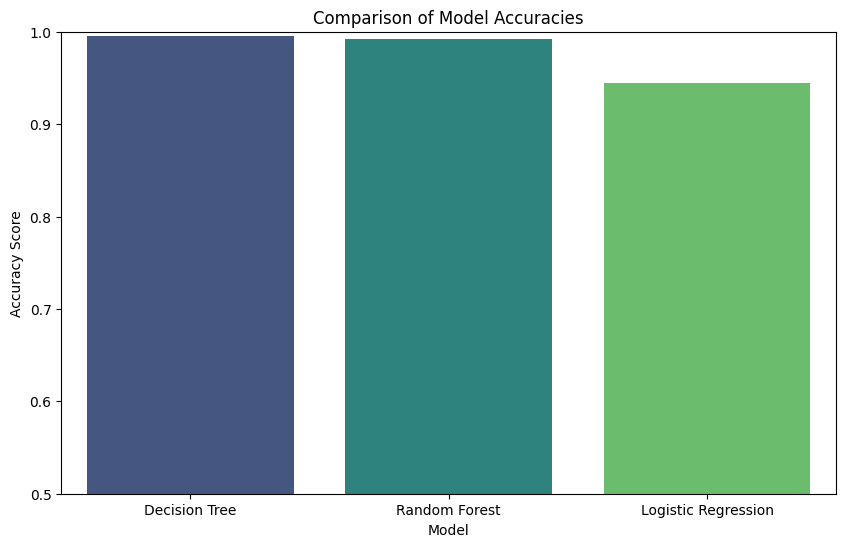

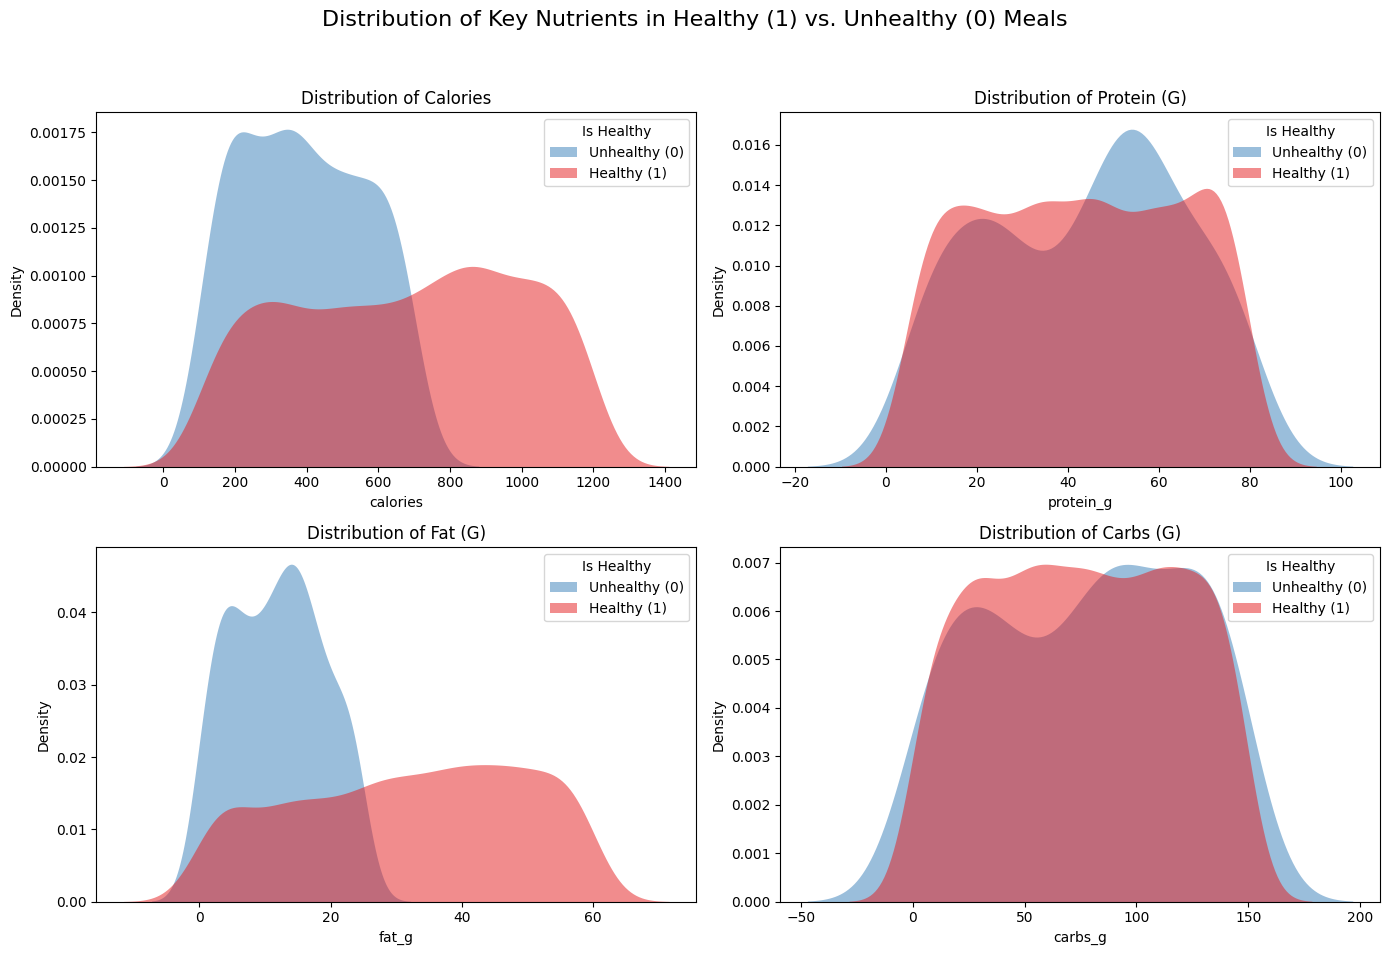

/tmp/ipython-input-3826497236.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cuisine', y='Avg_Healthy_Score', data=cuisine_analysis, palette='magma')


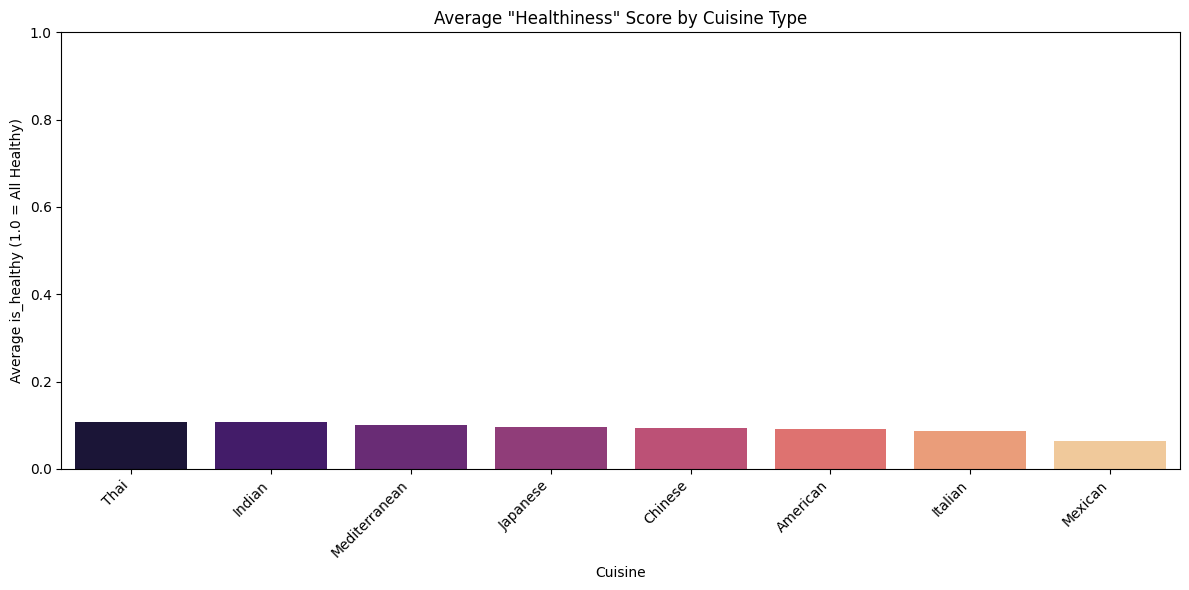


--- Summary of Analysis ---
The best performing model based on F1-Score is: Decision Tree

Key insights from nutritional distributions:
- Meals marked as healthy (1) tend to have different distributions of calories, protein, and fat.
- For instance, low-calorie meals are more likely to be marked as healthy, while a high protein/fat/carb meal may or may not be healthy depending on other factors (like fiber and sodium).


/tmp/ipython-input-3826497236.py:218: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='crest')


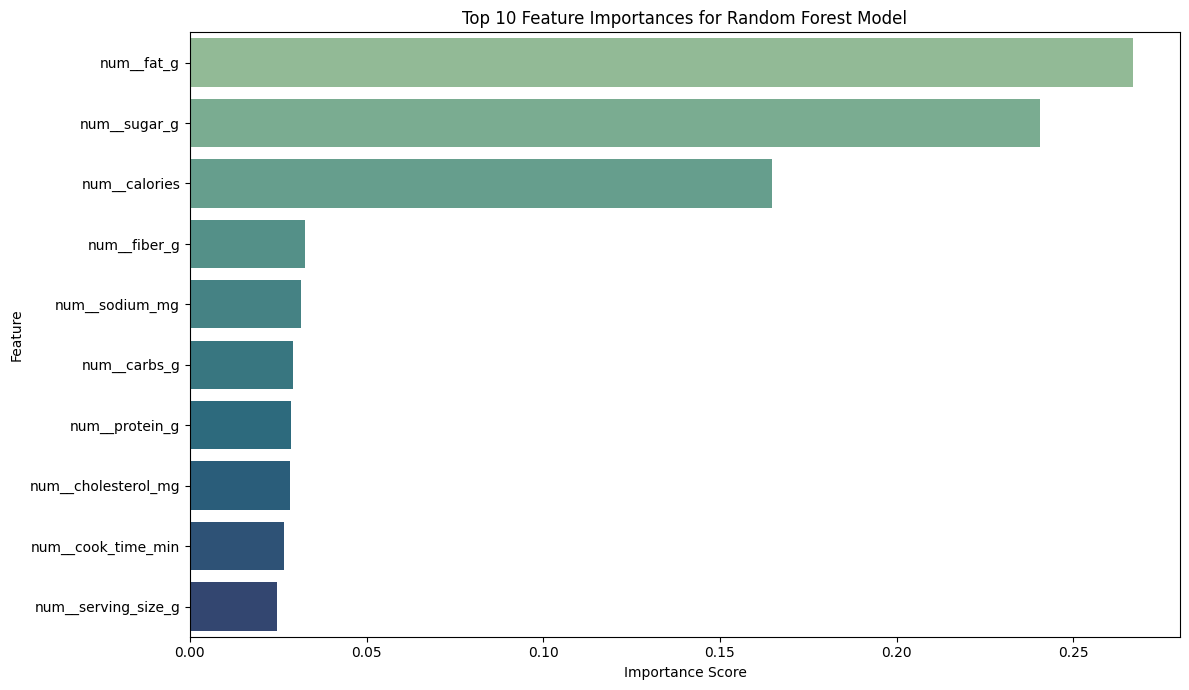


Top 10 most important features for prediction:
|                     |         0 |
|:--------------------|----------:|
| num__fat_g          | 0.26686   |
| num__sugar_g        | 0.240458  |
| num__calories       | 0.164847  |
| num__fiber_g        | 0.0326391 |
| num__sodium_mg      | 0.0315017 |
| num__carbs_g        | 0.0291771 |
| num__protein_g      | 0.0285261 |
| num__cholesterol_mg | 0.0282561 |
| num__cook_time_min  | 0.0266254 |
| num__serving_size_g | 0.0247751 |

Script execution finished. All models trained and results visualized.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time

FILE_PATH = 'healthy_eating_dataset.csv'
TARGET_COLUMN = 'is_healthy'

try:
    print(f"Loading dataset from: {FILE_PATH}...")
    df = pd.read_csv(FILE_PATH)
    print("Dataset loaded successfully. Shape:", df.shape)
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{FILE_PATH}' was not found.")
    print("Please ensure you have uploaded 'healthy_eating_dataset.csv' to your Colab environment.")
    exit()
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    exit()

# Data Cleaning and Preparation

df = df.drop(columns=['meal_id', 'meal_name', 'image_url'])

# 2. Handle missing values (if any)

print("\nChecking for missing values...")
print(df.isnull().sum().sort_values(ascending=False).head())


# 3. Feature and Target separation
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# categorical and numerical features for preprocessing

numerical_features = ['calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min', 'rating']
categorical_features = ['cuisine', 'meal_type', 'diet_type', 'cooking_method']

# Preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Standardize numerical features
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode categorical features
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- Phase 2: Model Development ---

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("\n--- Phase 2: Training Predictive Models ---")

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()

    # The full pipeline: Preprocessing + Model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Predict on the test set
    y_pred = pipeline.predict(X_test)
    end_time = time.time()

    # --- Phase 3: Model Comparison (Performance Metrics) ---
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion Matrix': cm,
        'Time (s)': round(end_time - start_time, 4)
    }

    print(f"{name} Training Complete. Time taken: {results[name]['Time (s)']} seconds")
    print(f"Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f}")

#  Model Comparison Table Display
print("\n--- Phase 3: Model Performance Comparison ---")
metrics_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [r['Accuracy'] for r in results.values()],
    'Precision': [r['Precision'] for r in results.values()],
    'Recall': [r['Recall'] for r in results.values()],
    'F1-Score': [r['F1-Score'] for r in results.values()],
    'Training Time (s)': [r['Time (s)'] for r in results.values()]
}).sort_values(by='F1-Score', ascending=False)

print(metrics_df.to_markdown(index=False))

# --- Phase 4: Visualization & Analysis ---
print("\n--- Phase 4: Visualization and Analysis ---")

# 1. Compare Accuracy of Models
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy Score')
plt.show()

# 2. Nutritional Distribution in Healthy vs. Unhealthy Meals
nutrients = ['calories', 'protein_g', 'fat_g', 'carbs_g']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Nutrients in Healthy (1) vs. Unhealthy (0) Meals', fontsize=16)

for i, nutrient in enumerate(nutrients):
    row = i // 2
    col = i % 2
    sns.kdeplot(df, x=nutrient, hue='is_healthy', fill=True, common_norm=False, ax=axes[row, col], palette='Set1', alpha=.5, linewidth=0)
    axes[row, col].set_title(f'Distribution of {nutrient.replace("_g", " (g)").title()}')
    axes[row, col].legend(title='Is Healthy', labels=['Unhealthy (0)', 'Healthy (1)'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Analysis: Which Cuisines are generally considered 'Healthy'?
cuisine_analysis = df.groupby('cuisine')[TARGET_COLUMN].mean().sort_values(ascending=False).reset_index()
cuisine_analysis.rename(columns={'is_healthy': 'Avg_Healthy_Score'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='cuisine', y='Avg_Healthy_Score', data=cuisine_analysis, palette='magma')
plt.title('Average "Healthiness" Score by Cuisine Type')
plt.ylabel('Average is_healthy (1.0 = All Healthy)')
plt.xlabel('Cuisine')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

print("\n--- Summary of Analysis ---")
print(f"The best performing model based on F1-Score is: {metrics_df.iloc[0]['Model']}")
print("\nKey insights from nutritional distributions:")
print("- Meals marked as healthy (1) tend to have different distributions of calories, protein, and fat.")
print("- For instance, low-calorie meals are more likely to be marked as healthy, while a high protein/fat/carb meal may or may not be healthy depending on other factors (like fiber and sodium).")


try:
    
    rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
    rf_pipeline.fit(X_train, y_train)
    rf_classifier = rf_pipeline.named_steps['classifier']

    # Get feature names after one-hot encoding
    feature_names_out = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # Create a Series of feature importances
    feature_importances = pd.Series(rf_classifier.feature_importances_, index=feature_names_out)
    top_10_features = feature_importances.nlargest(10)

    # Plotting Feature Importance
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='crest')
    plt.title('Top 10 Feature Importances for Random Forest Model')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 most important features for prediction:")
    print(top_10_features.to_markdown())

except Exception as e:
    print(f"\nCould not determine feature importance for Random Forest (often due to complex pipeline): {e}")

print("\nScript execution finished. All models trained and results visualized.")